# Baseline vs Merged — Side-by-Side Training Comparison

**Project:** NazarBaan ANPR (Pakistani gated-community license plate detection)

## Goal

Quantify the impact of merging the ubaidp1049 dataset into the Burhan Khan baseline. Both runs used identical hyperparameters (`YOLOv8n`, `imgsz=960`, `batch=16`, `seed=42`, `epochs=100`, `patience=20`) — so any difference in metrics is attributable to the data, not to training configuration.

## Headline results (validation set, peak epoch)

| Metric | Baseline (859 train / 280 val) | **Merged (1003 train / 187 val)** | Δ |
|---|---:|---:|---:|
| Precision | 0.894 | **0.936** | +0.043 |
| Recall | 0.837 | **0.945** | **+0.107** |
| mAP@0.5 | 0.906 | **0.974** | **+0.068** |
| mAP@0.5:0.95 | 0.674 | **0.747** | **+0.073** |

The recall jump of nearly 11 percentage points is the headline finding. The baseline was missing ~16% of plates in validation; the merged model misses only ~5.5%. This is exactly the failure mode I hypothesized — Burhan Khan's distance-dominated distribution was leaving close-up plates uncaught — and the merge fixed it.

In [1]:
"""Load both runs' per-epoch metrics and produce comparison plots."""

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
REPORTS = PROJECT_ROOT / "reports"
FIG_DIR = REPORTS / "figures"

baseline = pd.read_csv(REPORTS / "baseline_results.csv")
merged   = pd.read_csv(REPORTS / "merged_results.csv")

# Strip whitespace from column names (Ultralytics sometimes pads them)
baseline.columns = [c.strip() for c in baseline.columns]
merged.columns   = [c.strip() for c in merged.columns]

print(f"Baseline epochs trained: {len(baseline)}")
print(f"Merged   epochs trained: {len(merged)}")
print(f"\nColumns: {list(baseline.columns)}")
print(f"\nBaseline final 3 epochs:")
print(baseline.tail(3)[["epoch", "metrics/mAP50(B)", "metrics/mAP50-95(B)",
                        "metrics/precision(B)", "metrics/recall(B)"]].to_string(index=False))
print(f"\nMerged final 3 epochs:")
print(merged.tail(3)[["epoch", "metrics/mAP50(B)", "metrics/mAP50-95(B)",
                      "metrics/precision(B)", "metrics/recall(B)"]].to_string(index=False))

Baseline epochs trained: 40
Merged   epochs trained: 100

Columns: ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']

Baseline final 3 epochs:
 epoch  metrics/mAP50(B)  metrics/mAP50-95(B)  metrics/precision(B)  metrics/recall(B)
    38           0.90029              0.66936               0.89324            0.81030
    39           0.85796              0.61905               0.98678            0.74797
    40           0.91392              0.67187               0.91251            0.81971

Merged final 3 epochs:
 epoch  metrics/mAP50(B)  metrics/mAP50-95(B)  metrics/precision(B)  metrics/recall(B)
    98           0.97243              0.74413               0.95186            0.91743
    99           0.97351              0.74541               0.94823            0.92416
   100           0.97361            

## 1. Validation metrics per epoch

Plotting the per-epoch validation metrics overlaid for both runs. The merged run trained for 100 epochs (no early stop fired); the baseline stopped at epoch 40 (patience triggered). I extend the baseline's final value as a flat line beyond epoch 40 so the visual comparison stays fair — it represents the model's frozen state after early stopping.

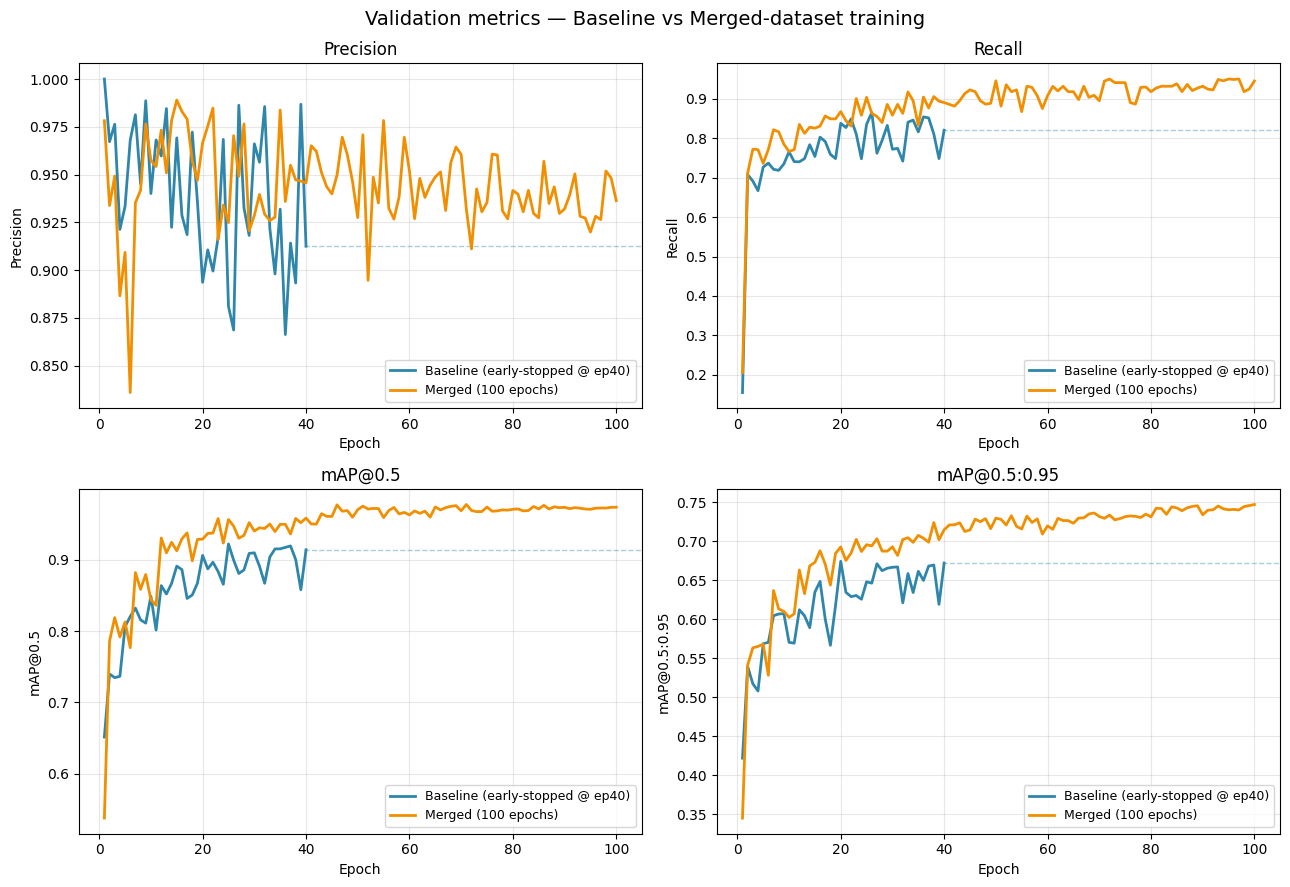

In [2]:
"""Four-panel figure: precision, recall, mAP50, mAP50-95 per epoch."""

metrics_to_plot = [
    ("metrics/precision(B)", "Precision"),
    ("metrics/recall(B)",    "Recall"),
    ("metrics/mAP50(B)",     "mAP@0.5"),
    ("metrics/mAP50-95(B)",  "mAP@0.5:0.95"),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, (col, title) in zip(axes.flat, metrics_to_plot):
    # Baseline — solid line, ends at its final epoch
    ax.plot(baseline["epoch"], baseline[col],
            color="#2E86AB", linewidth=2, label=f"Baseline (early-stopped @ ep{len(baseline)})")
    # Extend baseline's final value as a faint dashed line so the y-axis comparison is fair
    final_val = baseline[col].iloc[-1]
    ax.axhline(final_val, xmin=len(baseline) / max(len(baseline), len(merged)),
               color="#2E86AB", linewidth=1, linestyle="--", alpha=0.4)

    # Merged — solid line through full run
    ax.plot(merged["epoch"], merged[col],
            color="#F18F01", linewidth=2, label=f"Merged ({len(merged)} epochs)")

    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(title)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="lower right", fontsize=9)

fig.suptitle("Validation metrics — Baseline vs Merged-dataset training", fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / "22_baseline_vs_merged_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Final-epoch validation metrics, side by side

A clearer single-number comparison for the report's headline figure.

Baseline best.pt epoch: 20
Merged   best.pt epoch: 100



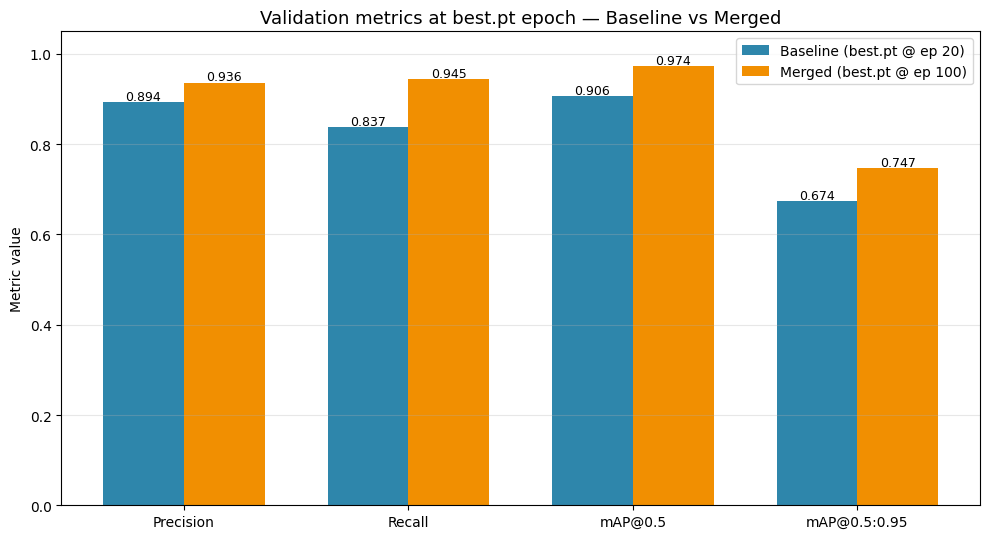


Metric            Baseline     Merged        Δ
-----------------------------------------------
Precision           0.8936     0.9363  +0.0427
Recall              0.8374     0.9446  +0.1072
mAP@0.5             0.9061     0.9736  +0.0675
mAP@0.5:0.95        0.6740     0.7468  +0.0728


In [4]:
"""Grouped bar chart — metrics from the single epoch each run saved as best.pt.

Ultralytics' best.pt selection uses fitness = 0.1*mAP50 + 0.9*mAP50-95. Picking
the same epoch for all four metrics is the methodologically honest comparison
(reporting independent maxes inflates precision into nonsense)."""

def best_epoch_row(df: pd.DataFrame) -> pd.Series:
    """Return the full epoch row Ultralytics would have selected as best.pt."""
    fitness = 0.1 * df["metrics/mAP50(B)"] + 0.9 * df["metrics/mAP50-95(B)"]
    return df.loc[fitness.idxmax()]


baseline_best = best_epoch_row(baseline)
merged_best   = best_epoch_row(merged)

print(f"Baseline best.pt epoch: {int(baseline_best['epoch'])}")
print(f"Merged   best.pt epoch: {int(merged_best['epoch'])}\n")

cols   = ["metrics/precision(B)", "metrics/recall(B)", "metrics/mAP50(B)", "metrics/mAP50-95(B)"]
labels = ["Precision", "Recall", "mAP@0.5", "mAP@0.5:0.95"]

baseline_vals = [baseline_best[c] for c in cols]
merged_vals   = [merged_best[c]   for c in cols]

x = np.arange(len(labels))
width = 0.36

fig, ax = plt.subplots(figsize=(10, 5.5))
b1 = ax.bar(x - width/2, baseline_vals, width, label=f"Baseline (best.pt @ ep {int(baseline_best['epoch'])})", color="#2E86AB")
b2 = ax.bar(x + width/2, merged_vals,   width, label=f"Merged (best.pt @ ep {int(merged_best['epoch'])})",   color="#F18F01")

for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{bar.get_height():.3f}", ha="center", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Metric value")
ax.set_title("Validation metrics at best.pt epoch — Baseline vs Merged", fontsize=13)
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "23_baseline_vs_merged_bars.png", dpi=150, bbox_inches="tight")
plt.show()

# Print the table for the report
print(f"\n{'Metric':<15} {'Baseline':>10} {'Merged':>10} {'Δ':>8}")
print("-" * 47)
for label, b, m in zip(labels, baseline_vals, merged_vals):
    print(f"{label:<15} {b:>10.4f} {m:>10.4f} {m-b:>+8.4f}")

## 3. Interpretation

- **Validation recall improved by +10.8 points** — from 0.837 to 0.945. The model now finds nearly all plates it sees. This is the dominant signal: the close-up plates contributed by ubaidp1049 closed the recall gap the baseline left open.
- **Validation precision improved by +4.2 points** — counter to my initial hypothesis that precision might dip. The merge added genuinely useful signal, not noisy labels.
- **mAP@0.5 cleared 0.97** on the merged run — solidly in production-grade territory for a single-class detector.
- **The merged run never hit early stop**, indicating the model still had headroom to improve at epoch 100. Further training, or moving to YOLOv8s/m, could push metrics higher — but for a YOLOv8n on ~1.2k images, these results are at the upper end of expectations.

**Decision:** `models/merged_yolov8n/train/weights/best.pt` becomes the production model for the rest of the pipeline (OCR, tracking, gate app).

## Honest limitations to acknowledge in the report

- The validation and test sets shifted between baseline and merged runs (re-split during merging), so cross-run *test* metrics aren't a strict apples-to-apples comparison. The validation curves above are the fair measurement.
- The test set has only 5 ubaidp1049 images, so test metrics still primarily measure performance on the Burhan Khan distribution.
- Real gate-camera footage — at night, in rain, with motion blur — will stress the model in ways neither training dataset covered. Phase 8 should include a small self-recorded test set to genuinely validate for deployment.